Average Cosine Similarity: 0.3052


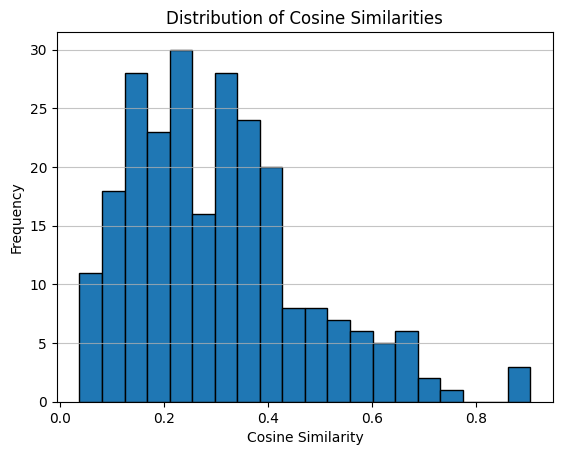

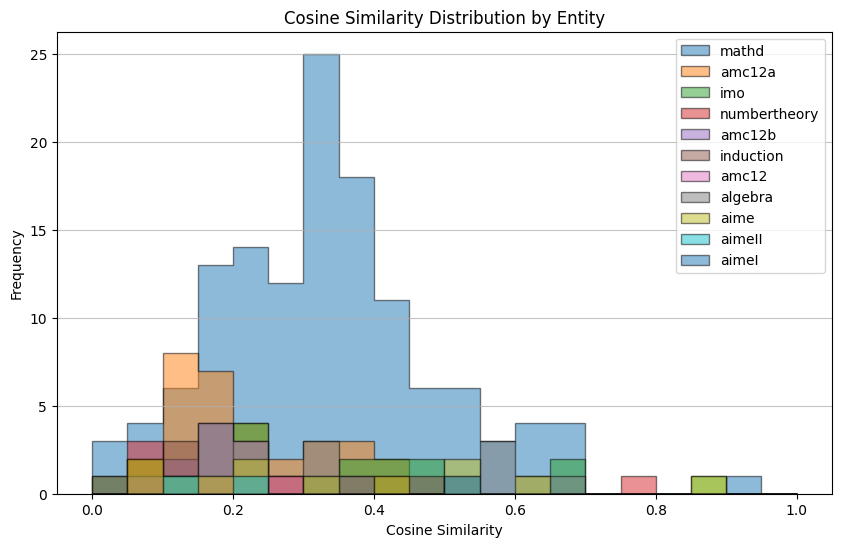

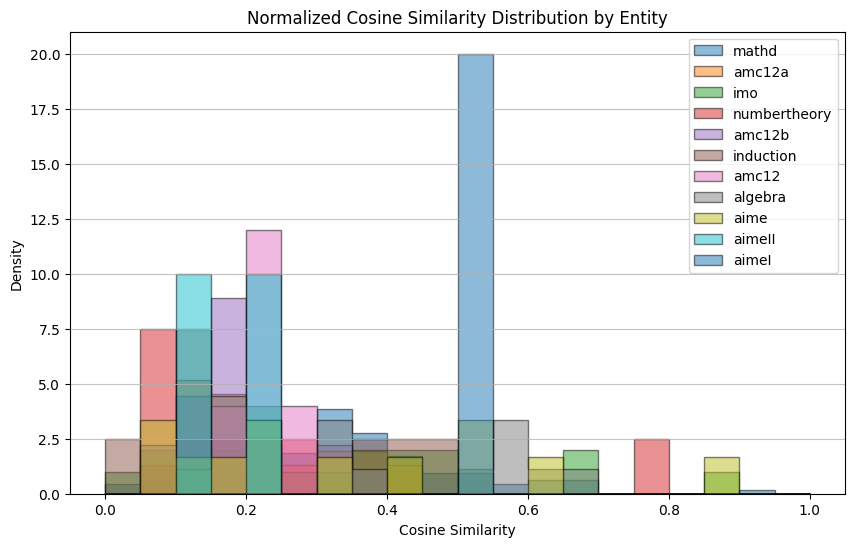

In [1]:
# Perform cosine similarity comparison between gpt_natural_s and natural_s
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Load results from file
with open('gpt_translations_latex.json', 'r') as f:
    results = json.load(f)

similarities = {}
vectorizer = TfidfVectorizer()

for entry, data in results.items():
    texts = [data['natural_s'], data['gpt_natural_s']]
    tfidf = vectorizer.fit_transform(texts)
    sim = cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
    similarities[entry] = sim

print(f"Average Cosine Similarity: {np.mean(list(similarities.values())):.4f}")

# Create distribution of similarities
similarity_values = list(similarities.values())
plt.hist(similarity_values, bins=20, edgecolor='black')
plt.title('Distribution of Cosine Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Distribution of Cosine Similarities by entity name (first part before underscore)
entity_groups = defaultdict(list)
for entry, sim in similarities.items():
    entity = entry.split('_')[0]
    entity_groups[entity].append(sim)

# Plot each entity's distribution
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
plt.figure(figsize=(10, 6))
for entity, sims in entity_groups.items():
    plt.hist(sims, bins=bins, alpha=0.5, label=entity, edgecolor='black', histtype='stepfilled')
plt.title('Cosine Similarity Distribution by Entity')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(10, 6))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
for entity, sims in entity_groups.items():
    plt.hist(sims, bins=bins, alpha=0.5, label=entity, density=True, edgecolor='black', histtype='stepfilled')
plt.title('Normalized Cosine Similarity Distribution by Entity')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [7]:
"""
Replicate paper-style distributions with smooth curves (Original vs Paraphrased):
  1) Sentence Length
  2) Syntactic Depth (requires spaCy parser; skipped if unavailable)
  3) Lexical Diversity

INPUT JSON format (example):
{
  "id_1": {"natural_s": "original text ...", "gpt_natural_s": "paraphrased text ..."},
  "id_2": {"natural_s": "...", "gpt_natural_s": "..."},
  ...
}

Usage:
- Put your JSON path in JSON_PATH, or pass via env JSON_PATH.
- For syntactic depth: `pip install spacy` and `python -m spacy download en_core_web_sm`
- Run, then open the saved PNGs.

Notes:
- No seaborn.
- One figure per chart.
- No explicit colors set (uses matplotlib defaults).
"""

import os, json, re, math
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt

JSON_PATH = os.getenv("JSON_PATH", "gpt_translations_latex.json")

# -------------------- Basic tokenization --------------------
WORD_RE = re.compile(r"[A-Za-z0-9_']+")

def toks(text: str) -> List[str]:
    return WORD_RE.findall((text or "").lower())

def sentence_length(text: str) -> int:
    return len(toks(text))

def lexical_diversity(text: str) -> float:
    T = toks(text)
    return (len(set(T)) / len(T)) if T else 0.0


# --- add these helpers near the top of your script ---

def ensure_spacy_parser():
    """
    Returns (spacy, nlp_with_parser) or (None, None) if unavailable.
    Will attempt to download en_core_web_sm if missing.
    """
    try:
        import spacy
        try:
            nlp = spacy.load("en_core_web_sm")
        except OSError:
            # Try to download the small English model
            try:
                from spacy.cli import download
                download("en_core_web_sm")
                nlp = spacy.load("en_core_web_sm")
            except Exception:
                return None, None

        # Must have a trained parser in the pipeline
        if not nlp.has_pipe("parser"):
            return None, None
        return spacy, nlp
    except Exception:
        return None, None


def syntactic_depth_doc(doc) -> float:
    """Max absolute dependency distance (|head.i - token.i|)."""
    if not doc:
        return 0.0
    m = 0
    for tok in doc:
        # skip roots (their head is themselves)
        if tok.head is tok:
            continue
        d = abs(tok.head.i - tok.i)
        if d > m:
            m = d
    return float(m)


# -------------------- Optional syntactic depth (spaCy) --------------------
def try_spacy():
    try:
        import spacy  # type: ignore
    except Exception:
        return None, None
    nlp = None
    for name in ("en_core_web_sm", "en_core_web_md", "en_core_web_lg"):
        try:
            nlp = spacy.load(name)
            break
        except Exception:
            continue
    return (spacy if nlp else None), nlp

def syntactic_depth(text: str, nlp) -> float:
    """
    Define syntactic depth as the maximum absolute dependency distance
    (max |head_index - token_index|), a simple proxy used in prior work.
    """
    if not text:
        return 0.0
    doc = nlp(text)
    if not doc:
        return 0.0
    m = 0
    for tok in doc:
        if tok.head is tok:
            continue
        m = max(m, abs(tok.head.i - tok.i))
    return float(m)

# --- SBERT helpers ---
from typing import Optional
import numpy as np

def _cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    # a, b: (d,) arrays
    an = np.linalg.norm(a)
    bn = np.linalg.norm(b)
    if an == 0 or bn == 0:
        return 0.0
    return float(np.dot(a, b) / (an * bn))

def load_sbert(model_name: str = "sentence-transformers/all-MiniLM-L6-v2"):
    """
    Try to load a Sentence-Transformer. Returns (model, tokenizer) or (None, None) if unavailable.
    """
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(model_name, device="cpu")
        return model
    except Exception as e:
        print(f"Sentence-BERT model not available ({e}). Skipping semantic similarity.")
        return None

def sbert_pairwise_cosine(pairs, model) -> list:
    """
    pairs: List[(orig_text, para_text)]
    model: SentenceTransformer
    Returns list[float] cosine similarities.
    """
    # Flatten and encode in one shot for efficiency
    texts = []
    for o, p in pairs:
        texts.append(o or "")
        texts.append(p or "")
    embs = model.encode(texts, batch_size=64, convert_to_numpy=True, normalize_embeddings=False)
    sims = []
    for i in range(0, len(embs), 2):
        sims.append(_cosine_sim(embs[i], embs[i+1]))
    return sims


# -------------------- Smooth KDE (no SciPy) --------------------
def gaussian_kde_curve(data: List[float], num_points=256):
    """
    Returns (xs, ys) KDE using Gaussian kernel with Silverman's rule-of-thumb bandwidth.
    Works for non-negative supports by auto-setting domain to [min-Δ, max+Δ].
    """
    arr = np.asarray([x for x in data if np.isfinite(x)], dtype=float)
    n = arr.size
    if n == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    std = np.std(arr)
    if std <= 0:
        # all points identical -> spike; render a tiny bump
        x0 = arr[0]
        xs = np.linspace(x0 - 1.0, x0 + 1.0, num_points)
        ys = np.zeros_like(xs)
        ys[np.argmin(np.abs(xs - x0))] = 1.0
        return xs, ys
    # Silverman's bandwidth
    h = 1.06 * std * (n ** (-1/5))
    lo = np.min(arr) - 3*h
    hi = np.max(arr) + 3*h
    xs = np.linspace(lo, hi, num_points)
    # Gaussian kernel density
    diffs = (xs[:, None] - arr[None, :]) / h  # shape (num_points, n)
    ks = np.exp(-0.5 * diffs**2) / (np.sqrt(2*np.pi) * h)
    ys = ks.mean(axis=1)
    return xs, ys

def plot_density_pair(values_a: List[float], values_b: List[float],
                      label_a: str, label_b: str,
                      title: str, xlabel: str, outfile: str):
    xs_a, ys_a = gaussian_kde_curve(values_a)
    xs_b, ys_b = gaussian_kde_curve(values_b)

    fig, ax = plt.subplots(figsize=(7, 4.6))
    ax.plot(xs_a, ys_a, label=label_a)
    ax.plot(xs_b, ys_b, label=label_b)

    # Means as vertical lines (dashed for A, dotted for B)
    if len(values_a) > 0:
        ax.axvline(float(np.mean(values_a)), linestyle="--")
    if len(values_b) > 0:
        ax.axvline(float(np.mean(values_b)), linestyle=":")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(outfile, dpi=160)
    plt.close(fig)

# -------------------- Load pairs --------------------
if not os.path.exists(JSON_PATH):
    raise FileNotFoundError(f"JSON not found at {JSON_PATH}")

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

pairs: List[Tuple[str, str]] = []
for _, rec in data.items():
    orig = rec.get("natural_s") or ""
    para = rec.get("gpt_natural_s") or ""
    pairs.append((orig, para))

if not pairs:
    raise RuntimeError("No (natural_s, gpt_natural_s) pairs found in the JSON.")

# -------------------- Compute metrics --------------------
orig_len, para_len = [], []
orig_ld,  para_ld  = [], []
orig_sd,  para_sd  = [], []

# sentence length & lexical diversity
for o, p in pairs:
    orig_len.append(sentence_length(o))
    para_len.append(sentence_length(p))
    orig_ld.append(lexical_diversity(o))
    para_ld.append(lexical_diversity(p))


spacy_mod, nlp = ensure_spacy_parser()
import spacy, en_core_web_sm
nlp = en_core_web_sm.load()

if nlp is not None:
    # Parse in batches for speed; keep the parser enabled
    originals = [o for o, _ in pairs]
    paras     = [p for _, p in pairs]

    # You can tune batch_size for your machine
    orig_docs = list(nlp.pipe(originals, batch_size=64))
    para_docs = list(nlp.pipe(paras,     batch_size=64))

    orig_sd = [syntactic_depth_doc(doc) for doc in orig_docs]
    para_sd = [syntactic_depth_doc(doc) for doc in para_docs]
    has_parser = True
else:
    print("spaCy parser not available (install en_core_web_sm). Skipping syntactic depth.")
    has_parser = False


# -------------------- Plot 3 paper-style curves --------------------
os.makedirs("figs_paper_style", exist_ok=True)

plot_density_pair(
    orig_len, para_len,
    label_a="Original", label_b="Paraphrased",
    title="Sentence Length Distribution",
    xlabel="Sentence Length (tokens)",
    outfile="figs_paper_style/sentence_length.png",
)

if has_parser and len(orig_sd) and len(para_sd):
    plot_density_pair(
        orig_sd, para_sd,
        label_a="Original", label_b="Paraphrased",
        title="Syntactic Depth Distribution",
        xlabel="Syntactic Depth (max dependency distance)",
        outfile="figs_paper_style/syntactic_depth.png",
    )
else:
    print("Syntactic depth plot skipped (spaCy parser not available).")

plot_density_pair(
    orig_ld, para_ld,
    label_a="Original", label_b="Paraphrased",
    title="Lexical Diversity Distribution",
    xlabel="Lexical Diversity (unique / total tokens)",
    outfile="figs_paper_style/lexical_diversity.png",
)

def plot_density(values: list, label: str, title: str, xlabel: str, outfile: str):
    xs, ys = gaussian_kde_curve(values)

    fig, ax = plt.subplots(figsize=(7, 4.6))
    (line,) = ax.plot(xs, ys, label=label, linewidth=1.8, zorder=3)
    ax.fill_between(xs, ys, 0.0,
                    where=(ys > 0),
                    interpolate=True,
                    color=line.get_color(),
                    alpha=0.45,
                    linewidth=0,
                    zorder=2)

    if values:
        ax.axvline(float(np.mean(values)), linestyle="--", linewidth=1, zorder=4)

    ax.set_ylim(bottom=0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(outfile, dpi=160)
    plt.close(fig)

import os
import glob

def load_sbert(model_name_or_path: str | None = None):
    """
    Load a SentenceTransformer from a local path if provided/available.
    Falls back to the default HF name only if no local path is found.
    """
    try:
        from sentence_transformers import SentenceTransformer
    except Exception as e:
        print(f"sentence-transformers not installed: {e}")
        return None

    # Prefer explicit arg, then SBERT_PATH env, else None
    candidate = "/Users/hmmoore/Desktop/AutoFormalization/sentence-transformers/all-MiniLM-L6-v2"

    def _looks_like_model_dir(p: str) -> bool:
        return os.path.isdir(p) and any(
            os.path.isfile(os.path.join(p, f))
            for f in ("config.json", "modules.json", "model.safetensors", "pytorch_model.bin")
        )

    # If user gave a root dir that contains subdirs, pick the first valid subdir
    def _pick_subdir(root: str) -> str | None:
        for sub in sorted(glob.glob(os.path.join(root, "*"))):
            if _looks_like_model_dir(sub):
                return sub
        return None

    if candidate:
        if _looks_like_model_dir(candidate):
            try:
                return SentenceTransformer(candidate, device="cpu")
            except Exception as e:
                print(f"Failed to load local SBERT at {candidate}: {e}")
        else:
            sub = _pick_subdir(candidate)
            if sub:
                try:
                    return SentenceTransformer(sub, device="cpu")
                except Exception as e:
                    print(f"Failed to load local SBERT at {sub}: {e}")

    # Last resort: named model (will require internet unless cached)
    try:
        return SentenceTransformer("/Users/hmmoore/Desktop/AutoFormalization/sentence-transformers/all-MiniLM-L6-v2", device="cpu")
    except Exception as e:
        print(f"Could not load SBERT (no local path and remote unavailable): {e}")
        return None


# --------- SBERT Semantic Similarity (Original NL vs Paraphrased NL) ---------
sbert_model = load_sbert()  # "sentence-transformers/all-MiniLM-L6-v2" by default
if sbert_model is not None:
    sbert_sims = sbert_pairwise_cosine(pairs, sbert_model)
    os.makedirs("figs_paper_style", exist_ok=True)
    plot_density(
        sbert_sims,
        label="Sentence-BERT Cosine Similarity",
        title="Semantic Similarity (Original vs Paraphrased)",
        xlabel="Cosine Similarity (SBERT)",
        outfile="figs_paper_style/semantic_similarity_sbert.png",
    )
    print("Saved SBERT similarity figure to figs_paper_style/semantic_similarity_sbert.png")
else:
    print("SBERT model unavailable; skipping semantic similarity.")


# ---------- Grammar similarity via dependency triples ----------

def ensure_spacy_parser_local():
    """
    Load a locally installed spaCy English model with a parser.
    Never downloads. Returns nlp or None.
    """
    try:
        import spacy
        try:
            import en_core_web_sm
            nlp = en_core_web_sm.load()
        except Exception:
            nlp = spacy.load("en_core_web_sm")
        return nlp if nlp.has_pipe("parser") else None
    except Exception:
        return None

def dep_triples(doc):
    """
    Represent grammar as dependency triples:
      (dep_label, head_POS, child_POS)
    Returns a list (multiset) so we can count frequencies.
    """
    triples = []
    for tok in doc:
        if tok.head is tok:  # skip root self-loop
            continue
        triples.append((tok.dep_.lower(), tok.head.pos_, tok.pos_))
    return triples

def cosine_from_counts(counts_a: dict, counts_b: dict) -> float:
    import math
    # Build shared vocabulary
    keys = set(counts_a) | set(counts_b)
    if not keys:
        return 0.0
    # Dot and norms
    dot = sum(counts_a.get(k, 0) * counts_b.get(k, 0) for k in keys)
    na  = math.sqrt(sum(v*v for v in counts_a.values()))
    nb  = math.sqrt(sum(v*v for v in counts_b.values()))
    if na == 0.0 or nb == 0.0:
        return 0.0
    return float(dot / (na * nb))

def grammatical_similarity(nlp, text_a: str, text_b: str) -> float:
    """
    Cosine similarity between dependency triple frequency vectors.
    """
    if not (text_a or text_b):
        return 0.0
    da, db = nlp(text_a), nlp(text_b)
    ta, tb = dep_triples(da), dep_triples(db)
    from collections import Counter
    ca, cb = Counter(ta), Counter(tb)
    return cosine_from_counts(ca, cb)

def plot_density(values: list, label: str, title: str, xlabel: str, outfile: str):
    xs, ys = gaussian_kde_curve(values)
    fig, ax = plt.subplots(figsize=(7, 4.6))
    (line,) = ax.plot(xs, ys, label=label, linewidth=1.8, zorder=3)
    ax.fill_between(xs, ys, 0.0, where=(ys > 0), interpolate=True,
                    color=line.get_color(), alpha=0.45, linewidth=0, zorder=2)
    if values:
        ax.axvline(float(np.mean(values)), linestyle="--", linewidth=1, zorder=4)
    ax.set_ylim(bottom=0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(outfile, dpi=160)
    plt.close(fig)


# ---------- Grammatical similarity distribution ----------
nlp_g = ensure_spacy_parser_local()
if nlp_g is not None:
    gram_sims = []
    # batch for speed
    originals = [o for o, _ in pairs]
    paras     = [p for _, p in pairs]
    orig_docs = list(nlp_g.pipe(originals, batch_size=64))
    para_docs = list(nlp_g.pipe(paras,     batch_size=64))

    from collections import Counter
    for da, db in zip(orig_docs, para_docs):
        ta, tb = dep_triples(da), dep_triples(db)
        gram_sims.append(cosine_from_counts(Counter(ta), Counter(tb)))

    os.makedirs("figs_paper_style", exist_ok=True)
    plot_density(
        gram_sims,
        label="Grammar Similarity (dep triples, cosine)",
        title="Grammatical Similarity — Original vs Paraphrased",
        xlabel="Cosine Similarity",
        outfile="figs_paper_style/grammar_similarity.png",
    )
    print("Saved grammatical similarity figure to figs_paper_style/grammar_similarity.png")
else:
    print("spaCy parser not available locally; skipping grammatical similarity.")


print("Saved figures to ./figs_paper_style")




Saved SBERT similarity figure to figs_paper_style/semantic_similarity_sbert.png
Saved grammatical similarity figure to figs_paper_style/grammar_similarity.png
Saved figures to ./figs_paper_style
